# Clustering — Category Recap

> **Goal:** group points so that similar ones are together and dissimilar ones are apart, **without** labels.

This notebook ties together the four clustering notebooks
into one decision panel and a head-to-head visual benchmark.

| # | Algorithm | Geometry assumed |
|---|---|---|
| 20 | K-Means | Spherical, equal-size |
| 21 | Hierarchical | Tree of merges, no shape |
| 22 | DBSCAN | Density-connected |
| 23 | GMM (Gaussian Mixture Model) | Gaussian ellipses |

## Cheat-sheet — clustering algorithm landscape

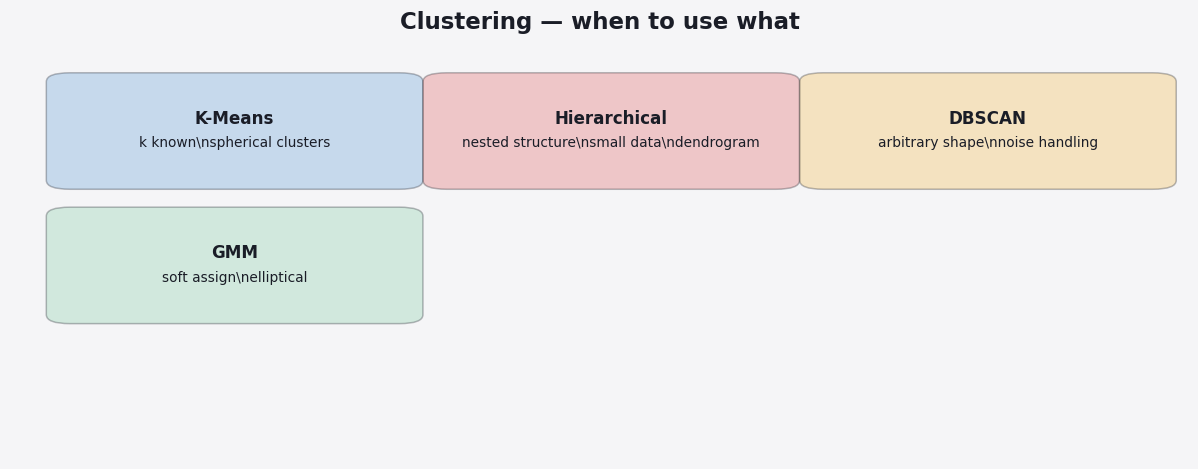

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
fig, ax = plt.subplots(figsize=(11, 4.4)); ax.axis('off')
ax.text(0.5, 0.96, 'Clustering — when to use what', ha='center', fontsize=15, weight='bold')
items = [('K-Means', 'k known\\nspherical clusters'), ('Hierarchical', 'nested structure\\nsmall data\\ndendrogram'), ('DBSCAN', 'arbitrary shape\\nnoise handling'), ('GMM', 'soft assign\\nelliptical')]
for k, (name, blurb) in enumerate(items):
    r, c = divmod(k, 3)
    x = 0.05 + c*0.32; y = 0.82 - r*0.30
    ax.add_patch(FancyBboxPatch((x, y-0.20), 0.28, 0.22, boxstyle='round,pad=0.02',
                                facecolor=P[k % len(P)], alpha=0.30, edgecolor='#1a1d27'))
    ax.text(x+0.14, y-0.04, name, ha='center', va='top', fontsize=11, weight='bold')
    ax.text(x+0.14, y-0.10, blurb, ha='center', va='top', fontsize=9, wrap=True)
ax.set_xlim(0,1); ax.set_ylim(0,1); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']


---
## Comparison

| Property | K-Means | Hierarchical | DBSCAN | GMM |
|---|---|---|---|---|
| Cluster shape | spherical | any (linkage-dep.) | arbitrary | ellipsoidal |
| Specify $k$ in advance | ✅ | ❌ (cut tree) | ❌ | ✅ |
| Detect outliers | ❌ | ❌ | ✅ noise label | partial |
| Soft membership | ❌ | ❌ | ❌ | ✅ |
| Scales to $n > 10^5$ | ✅ mini-batch | ❌ $O(n^2)$ mem | partial | ✅ |
| Variable density | ❌ | partial | ❌ (needs HDBSCAN) | ✅ |

---
## Decision rule

In [ ]:
from IPython.display import SVG, display
_svg = """\
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 760 355" width="760" height="355"
     style="font-family:'DejaVu Sans',sans-serif;background:#f5f5f7;border-radius:8px;">
  <line x1="380" y1="57" x2="112" y2="100" stroke="#c8ccd4" stroke-width="1.8"/>
  <line x1="380" y1="57" x2="542" y2="100" stroke="#c8ccd4" stroke-width="1.8"/>
  <line x1="542" y1="142" x2="405" y2="185" stroke="#c8ccd4" stroke-width="1.8"/>
  <line x1="542" y1="142" x2="623" y2="185" stroke="#c8ccd4" stroke-width="1.8"/>
  <line x1="623" y1="227" x2="503" y2="270" stroke="#c8ccd4" stroke-width="1.8"/>
  <line x1="623" y1="227" x2="678" y2="270" stroke="#c8ccd4" stroke-width="1.8"/>
  <text x="238" y="73" text-anchor="middle" font-size="11" font-weight="bold" fill="#5b9bd5">Yes</text>
  <text x="464" y="73" text-anchor="middle" font-size="11" font-weight="bold" fill="#e05c5c">No</text>
  <text x="463" y="159" text-anchor="end"   font-size="11" font-weight="bold" fill="#5b9bd5">Yes</text>
  <text x="587" y="159" text-anchor="start" font-size="11" font-weight="bold" fill="#e05c5c">No</text>
  <text x="558" y="247" text-anchor="end"   font-size="11" font-weight="bold" fill="#5b9bd5">Yes</text>
  <text x="643" y="247" text-anchor="start" font-size="11" font-weight="bold" fill="#e05c5c">No</text>
  <rect x="150" y="15" width="460" height="42" rx="6" fill="#5b9bd5" fill-opacity="0.15" stroke="#5b9bd5" stroke-width="1.5"/>
  <text x="380" y="32" text-anchor="middle" font-size="12" fill="#1a1d27">Clusters roughly spherical</text>
  <text x="380" y="48" text-anchor="middle" font-size="12" fill="#1a1d27">+ know k?</text>
  <rect x="10" y="100" width="205" height="38" rx="6" fill="#7ecba1" fill-opacity="0.25" stroke="#7ecba1" stroke-width="1.5"/>
  <text x="112" y="124" text-anchor="middle" font-size="12" fill="#1a1d27">K-Means</text>
  <rect x="377" y="100" width="330" height="42" rx="6" fill="#5b9bd5" fill-opacity="0.15" stroke="#5b9bd5" stroke-width="1.5"/>
  <text x="542" y="117" text-anchor="middle" font-size="12" fill="#1a1d27">Ellipsoidal shape</text>
  <text x="542" y="133" text-anchor="middle" font-size="12" fill="#1a1d27">or soft membership?</text>
  <rect x="318" y="185" width="175" height="38" rx="6" fill="#56b6c2" fill-opacity="0.25" stroke="#56b6c2" stroke-width="1.5"/>
  <text x="405" y="209" text-anchor="middle" font-size="12" fill="#1a1d27">GMM</text>
  <rect x="500" y="185" width="247" height="42" rx="6" fill="#5b9bd5" fill-opacity="0.15" stroke="#5b9bd5" stroke-width="1.5"/>
  <text x="623" y="201" text-anchor="middle" font-size="12" fill="#1a1d27">Density-defined</text>
  <text x="623" y="217" text-anchor="middle" font-size="12" fill="#1a1d27">or arbitrary shape?</text>
  <rect x="393" y="270" width="220" height="38" rx="6" fill="#f4b942" fill-opacity="0.25" stroke="#f4b942" stroke-width="1.5"/>
  <text x="503" y="294" text-anchor="middle" font-size="12" fill="#1a1d27">DBSCAN / HDBSCAN</text>
  <rect x="598" y="270" width="160" height="38" rx="6" fill="#c678dd" fill-opacity="0.25" stroke="#c678dd" stroke-width="1.5"/>
  <text x="678" y="285" text-anchor="middle" font-size="12" fill="#1a1d27">Hierarchical</text>
  <text x="678" y="301" text-anchor="middle" font-size="11" fill="#1a1d27">(Ward)</text>
</svg>"""
display(SVG(_svg))

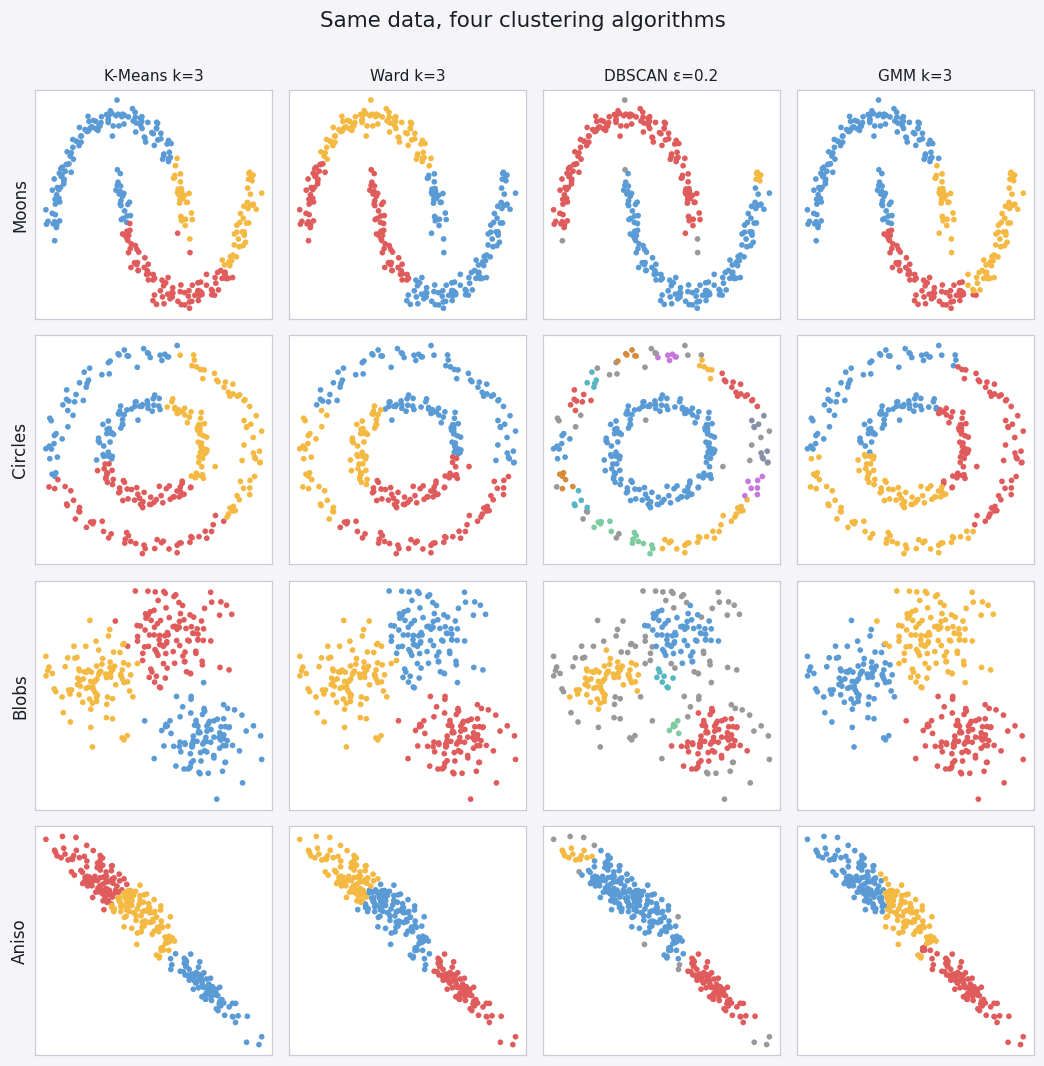

In [3]:
from sklearn.datasets import make_moons, make_blobs, make_circles
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

datasets = [
    ('Moons',  make_moons(n_samples=300, noise=0.06, random_state=0)[0]),
    ('Circles', make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=0)[0]),
    ('Blobs',  make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=0)[0]),
    ('Aniso',  StandardScaler().fit_transform(make_blobs(n_samples=300, centers=3, random_state=0)[0] @ np.array([[0.6,-0.6],[-0.4,0.8]]))),
]

algos = [
    ('K-Means k=3',     lambda X: KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(X)),
    ('Ward k=3',        lambda X: AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X)),
    ('DBSCAN ε=0.2',    lambda X: DBSCAN(eps=0.2, min_samples=5).fit_predict(X)),
    ('GMM k=3',         lambda X: GaussianMixture(n_components=3, random_state=0).fit_predict(X)),
]

fig, axes = plt.subplots(len(datasets), len(algos), figsize=(2.4*len(algos), 2.4*len(datasets)),
                          sharex=False, sharey=False)
for r, (dname, X) in enumerate(datasets):
    Xn = StandardScaler().fit_transform(X)
    for c, (aname, fn) in enumerate(algos):
        ax = axes[r, c]
        labels = fn(Xn)
        for k in np.unique(labels):
            mask = labels == k
            color = '#999' if k == -1 else PALETTE[k % len(PALETTE)]
            ax.scatter(Xn[mask,0], Xn[mask,1], s=14, color=color, edgecolors='none')
        if r == 0: ax.set_title(aname, fontsize=10)
        if c == 0: ax.set_ylabel(dname, fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('Same data, four clustering algorithms', y=1.005, fontsize=14)
fig.tight_layout()
plt.show()


---
## Reading the grid

- **Moons / Circles** — only DBSCAN finds the true non-convex clusters; everything else slices them in half.
- **Blobs** — all four work, but K-Means and GMM are the cleanest.
- **Anisotropic blobs** — GMM with full covariance shines because it actually models the elongated ellipses; K-Means assumes spherical and misses.

> Lesson: **shape assumptions matter more than algorithm choice**. Match the geometry first.
